In [50]:
#!pip install nixtla

In [1]:

import pandas as pd
from nixtla import NixtlaClient
nixtla_client = NixtlaClient(api_key = 'nixak-fdeb395c1c38014d4292173c77382d77112264957706fd4bfd4ba3ea8d27da243ee0fa406f4a8105')
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

In [2]:
## Load the data from file/files

In [3]:
#load data from cities

# 2. Read historic electricity demand data
df = pd.read_csv('pl_monthly.csv')
df

,utc_timestamp,PL_load_actual_entsoe_transparency
0,2015-01-01,604853.916667
1,2015-02-01,552283.791667
2,2015-03-01,586079.458333
3,2015-04-01,538041.375000
4,2015-05-01,535920.291667
5,2015-06-01,520290.250000
6,2015-07-01,550013.708333
7,2015-08-01,543721.791667
8,2015-09-01,540783.291667
9,2015-10-01,586850.291667


## Select training data based on Scenario

In [4]:
# Select data for training # 
fra = '2015'
til = '2019'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData

,utc_timestamp,PL_load_actual_entsoe_transparency
0,2015-01-01,604853.916667
1,2015-02-01,552283.791667
2,2015-03-01,586079.458333
3,2015-04-01,538041.375000
4,2015-05-01,535920.291667
5,2015-06-01,520290.250000
6,2015-07-01,550013.708333
7,2015-08-01,543721.791667
8,2015-09-01,540783.291667
9,2015-10-01,586850.291667


In [5]:
len(trainData)

48

## Validation data selection based on scenario

In [6]:
# Select data for validation # 
fra = '2019'
til = '2020'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,actual
48,2019-01-01,660228.166667
49,2019-02-01,577524.541667
50,2019-03-01,612992.875000
51,2019-04-01,558669.875000
52,2019-05-01,567931.625000
53,2019-06-01,557856.958333
54,2019-07-01,569100.750000
55,2019-08-01,565454.583333
56,2019-09-01,557759.291667
57,2019-10-01,607558.875000


In [7]:
len(validData)

12

## Forcasting wsith timeGPT

In [8]:
# 3. Forecast the next 24 hours
# First, ensure your DataFrame has the required column names
# Nixtla typically expects 'ds' for the timestamp column and 'y' for the target variable

# Assuming trainData has a datetime column with a different name (e.g., 'date' or 'timestamp')
# Rename it to match Nixtla's expected format
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'y'})

# Now try forecasting again
fcst_df = nixtla_client.forecast(trainData, 
                                 h=len(validData), 
                                 freq='MS',
                                 model='timegpt-1-long-horizon')

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


In [9]:
print("Train end:", trainData['ds'].max())
print("Forecast start:", fcst_df['ds'].min())
print("Valid start:", validData['ds'].min())

Train end: 2018-12-01
Forecast start: 2019-01-01 00:00:00
Valid start: 2019-01-01


In [10]:
fcst_df

,ds,TimeGPT
0,2019-01-01,643481.44
1,2019-02-01,608514.30
2,2019-03-01,629527.60
3,2019-04-01,579897.56
4,2019-05-01,578956.10
5,2019-06-01,576019.44
6,2019-07-01,583840.06
7,2019-08-01,591043.94
8,2019-09-01,586125.25
9,2019-10-01,615984.10


## Merge forecast n actual

In [11]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')
result

,ds,TimeGPT,actual
0,2019-01-01,643481.44,660228.166667
1,2019-02-01,608514.30,577524.541667
2,2019-03-01,629527.60,612992.875000
3,2019-04-01,579897.56,558669.875000
4,2019-05-01,578956.10,567931.625000
5,2019-06-01,576019.44,557856.958333
6,2019-07-01,583840.06,569100.750000
7,2019-08-01,591043.94,565454.583333
8,2019-09-01,586125.25,557759.291667
9,2019-10-01,615984.10,607558.875000


In [12]:
print(fcst_df.columns)
print(validData.columns)

Index(['ds', 'TimeGPT'], dtype='object')
Index(['ds', 'actual'], dtype='object')


## Metrics calculation (rRMSE and rMAE)

In [13]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['TimeGPT']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['TimeGPT'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.0380 rMAE: 0.0358 


## Comparison of GPT vs Actual

In [15]:
city = 'Monthly Poland TimeGPT'

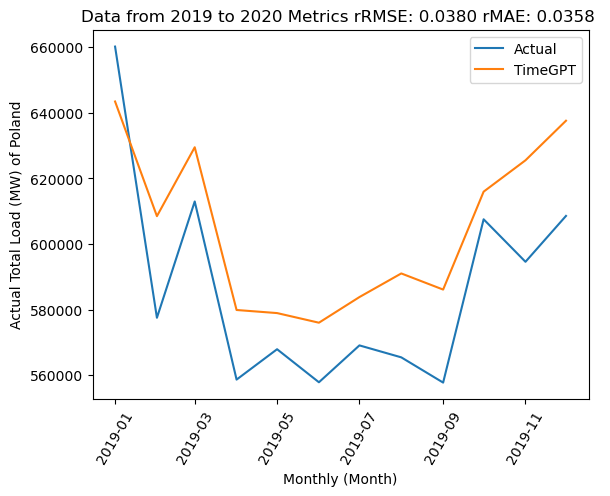

In [16]:
import matplotlib.pyplot as plt
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['TimeGPT'],label='TimeGPT')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Monthly (Month)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of Poland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
